# 3.1 Data Preparation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Download the data
# Look at the data
# Make column names and values looks uniform
# Check if all the columns read correctly
# Check if the churn variable needs any preparation

In [2]:
data = 'https://raw.githubusercontent.com/alexeygrigorev/mlbookcamp-code/master/chapter-03-churn-prediction/WA_Fn-UseC_-Telco-Customer-Churn.csv'

In [3]:
df = pd.read_csv(data)
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
cols = list(df.columns.str.replace(" ", "_").str.lower())
cols

['customerid',
 'gender',
 'seniorcitizen',
 'partner',
 'dependents',
 'tenure',
 'phoneservice',
 'multiplelines',
 'internetservice',
 'onlinesecurity',
 'onlinebackup',
 'deviceprotection',
 'techsupport',
 'streamingtv',
 'streamingmovies',
 'contract',
 'paperlessbilling',
 'paymentmethod',
 'monthlycharges',
 'totalcharges',
 'churn']

In [5]:
df.columns = cols
df.head()

,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,...,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
df['customerid'].str.lower().str.replace(" ", "_")

0       7590-vhveg
1       5575-gnvde
2       3668-qpybk
3       7795-cfocw
4       9237-hqitu
           ...    
7038    6840-resvb
7039    2234-xaduh
7040    4801-jzazl
7041    8361-ltmkd
7042    3186-ajiek
Name: customerid, Length: 7043, dtype: str

In [7]:
cols_str = list(df.dtypes[df.dtypes == 'str'].index)

In [8]:
for c in cols_str:
    df[c] = df[c].str.lower().str.replace(" ", "_")

df.head()   

,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,...,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn
0,7590-vhveg,female,0,yes,no,1,no,no_phone_service,dsl,no,...,no,no,no,no,month-to-month,yes,electronic_check,29.85,29.85,no
1,5575-gnvde,male,0,no,no,34,yes,no,dsl,yes,...,yes,no,no,no,one_year,no,mailed_check,56.95,1889.5,no
2,3668-qpybk,male,0,no,no,2,yes,no,dsl,yes,...,no,no,no,no,month-to-month,yes,mailed_check,53.85,108.15,yes
3,7795-cfocw,male,0,no,no,45,no,no_phone_service,dsl,yes,...,yes,yes,no,no,one_year,no,bank_transfer_(automatic),42.30,1840.75,no
4,9237-hqitu,female,0,no,no,2,yes,no,fiber_optic,no,...,no,no,no,no,month-to-month,yes,electronic_check,70.70,151.65,yes


In [9]:
df['churn'].head() == 'yes'

0    False
1    False
2     True
3    False
4     True
Name: churn, dtype: bool

In [10]:
for v in ['yes']:
    df['churn'] = (df['churn'] == v).astype(int)

df['churn'].head().values

array([0, 0, 1, 0, 1])

In [11]:
df.dtypes

customerid              str
gender                  str
seniorcitizen         int64
partner                 str
dependents              str
tenure                int64
phoneservice            str
multiplelines           str
internetservice         str
onlinesecurity          str
onlinebackup            str
deviceprotection        str
techsupport             str
streamingtv             str
streamingmovies         str
contract                str
paperlessbilling        str
paymentmethod           str
monthlycharges      float64
totalcharges            str
churn                 int64
dtype: object

In [12]:
# totalcharges to numeric
# tc = pd.to_numeric(df.totalcharges, errors='coerce')

In [13]:
df['churn']

0       0
1       0
2       1
3       0
4       1
       ..
7038    0
7039    0
7040    0
7041    1
7042    0
Name: churn, Length: 7043, dtype: int64

In [14]:
df['totalcharges']=pd.to_numeric(df['totalcharges'], errors='coerce')
df['totalcharges'].dtypes

dtype('float64')

In [15]:
df['totalcharges'] = df['totalcharges'].fillna(0)

In [16]:
df.totalcharges.isnull().sum()

np.int64(0)

In [17]:
df.dtypes

customerid              str
gender                  str
seniorcitizen         int64
partner                 str
dependents              str
tenure                int64
phoneservice            str
multiplelines           str
internetservice         str
onlinesecurity          str
onlinebackup            str
deviceprotection        str
techsupport             str
streamingtv             str
streamingmovies         str
contract                str
paperlessbilling        str
paymentmethod           str
monthlycharges      float64
totalcharges        float64
churn                 int64
dtype: object

In [18]:
df.T

,0,1,2,3,4,5,6,7,8,9,...,7033,7034,7035,7036,7037,7038,7039,7040,7041,7042
customerid,7590-vhveg,5575-gnvde,3668-qpybk,7795-cfocw,9237-hqitu,9305-cdskc,1452-kiovk,6713-okomc,7892-pookp,6388-tabgu,...,9767-fflem,0639-tsiqw,8456-qdavc,7750-eyxwz,2569-wgero,6840-resvb,2234-xaduh,4801-jzazl,8361-ltmkd,3186-ajiek
gender,female,male,male,male,female,female,male,female,female,male,...,male,female,male,female,female,male,female,female,male,male
seniorcitizen,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
partner,yes,no,no,no,no,no,no,no,yes,no,...,no,no,no,no,no,yes,yes,yes,yes,no
dependents,no,no,no,no,no,no,yes,no,no,yes,...,no,no,no,no,no,yes,yes,yes,no,no
tenure,1,34,2,45,2,8,22,10,28,62,...,38,67,19,12,72,24,72,11,4,66
phoneservice,no,yes,yes,no,yes,yes,yes,no,yes,yes,...,yes,yes,yes,no,yes,yes,yes,no,yes,yes
multiplelines,no_phone_service,no,no,no_phone_service,no,yes,yes,no_phone_service,yes,no,...,no,yes,no,no_phone_service,no,yes,yes,no_phone_service,yes,no
internetservice,dsl,dsl,dsl,dsl,fiber_optic,fiber_optic,fiber_optic,dsl,fiber_optic,dsl,...,fiber_optic,fiber_optic,fiber_optic,dsl,no,dsl,fiber_optic,dsl,fiber_optic,fiber_optic
onlinesecurity,no,yes,yes,yes,no,no,no,yes,no,yes,...,no,yes,no,no,no_internet_service,yes,no,yes,no,yes


In [19]:
df.totalcharges.isnull().sum()

np.int64(0)

# 3.2 Setting Up The Validation Framework

In [20]:
from sklearn.model_selection import train_test_split

In [21]:
df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=1)

In [22]:
df_full_train.shape, df_test.shape

((5634, 21), (1409, 21))

In [23]:
df_full_train.head()

,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,...,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn
1814,5442-pptjy,male,0,yes,yes,12,yes,no,no,no_internet_service,...,no_internet_service,no_internet_service,no_internet_service,no_internet_service,two_year,no,mailed_check,19.70,258.35,0
5946,6261-rcvns,female,0,no,no,42,yes,no,dsl,yes,...,yes,yes,no,yes,one_year,no,credit_card_(automatic),73.90,3160.55,1
3881,2176-osjuv,male,0,yes,no,71,yes,yes,dsl,yes,...,no,yes,no,no,two_year,no,bank_transfer_(automatic),65.15,4681.75,0
2389,6161-erdgd,male,0,yes,yes,71,yes,yes,dsl,yes,...,yes,yes,yes,yes,one_year,no,electronic_check,85.45,6300.85,0
3676,2364-ufrom,male,0,no,no,30,yes,no,dsl,yes,...,no,yes,yes,no,one_year,no,electronic_check,70.40,2044.75,0


In [24]:
df_full_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=1)
len(df_full_train), len(df_val), len(df_test)

(4225, 1409, 1409)

In [25]:
df_train = df_full_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

In [26]:
y_train = df_full_train.churn.values
y_train


array([0, 0, 1, ..., 1, 0, 1], shape=(4225,))

In [27]:
len(df_full_train), len(df_val), len(df_test)

(4225, 1409, 1409)

In [28]:
y_val = df_val.churn.values
y_val

array([0, 0, 0, ..., 0, 1, 1], shape=(1409,))

In [29]:
y_test = df_test.churn.values
y_test

array([0, 0, 0, ..., 0, 0, 1], shape=(1409,))

In [30]:
del df_train['churn']
del df_val['churn']
del df_test['churn']

In [31]:
df_train.columns

Index(['customerid', 'gender', 'seniorcitizen', 'partner', 'dependents',
       'tenure', 'phoneservice', 'multiplelines', 'internetservice',
       'onlinesecurity', 'onlinebackup', 'deviceprotection', 'techsupport',
       'streamingtv', 'streamingmovies', 'contract', 'paperlessbilling',
       'paymentmethod', 'monthlycharges', 'totalcharges'],
      dtype='str')

# 3.3 EDA

In [32]:
# Check missing values
# Look at target variable (churn)
# Look at numerical and categorical variables 
df_train.isnull().sum()

customerid          0
gender              0
seniorcitizen       0
partner             0
dependents          0
tenure              0
phoneservice        0
multiplelines       0
internetservice     0
onlinesecurity      0
onlinebackup        0
deviceprotection    0
techsupport         0
streamingtv         0
streamingmovies     0
contract            0
paperlessbilling    0
paymentmethod       0
monthlycharges      0
totalcharges        0
dtype: int64

In [33]:
df_full_train = df_full_train.reset_index(drop=True)

In [34]:
df_full_train.churn.value_counts(normalize=True)
# churn rate 1    0.268639

churn
0    0.731361
1    0.268639
Name: proportion, dtype: float64

In [35]:
global_churn_rate = df_full_train.churn.mean()
round(global_churn_rate, 2)

np.float64(0.27)

In [36]:
categorical = list(df_full_train.dtypes[df_full_train.dtypes == 'str'].index)

In [37]:
categorical.remove('customerid')

In [38]:
categorical

['gender',
 'partner',
 'dependents',
 'phoneservice',
 'multiplelines',
 'internetservice',
 'onlinesecurity',
 'onlinebackup',
 'deviceprotection',
 'techsupport',
 'streamingtv',
 'streamingmovies',
 'contract',
 'paperlessbilling',
 'paymentmethod']

In [39]:
list(df_full_train.dtypes[df_full_train.dtypes == 'str'].index)

['customerid',
 'gender',
 'partner',
 'dependents',
 'phoneservice',
 'multiplelines',
 'internetservice',
 'onlinesecurity',
 'onlinebackup',
 'deviceprotection',
 'techsupport',
 'streamingtv',
 'streamingmovies',
 'contract',
 'paperlessbilling',
 'paymentmethod']

In [40]:
categorical.insert(1, 'seniorcitizen')

In [41]:
categorical

['gender',
 'seniorcitizen',
 'partner',
 'dependents',
 'phoneservice',
 'multiplelines',
 'internetservice',
 'onlinesecurity',
 'onlinebackup',
 'deviceprotection',
 'techsupport',
 'streamingtv',
 'streamingmovies',
 'contract',
 'paperlessbilling',
 'paymentmethod']

In [42]:
df_full_train[categorical].nunique()

gender              2
seniorcitizen       2
partner             2
dependents          2
phoneservice        2
multiplelines       3
internetservice     3
onlinesecurity      3
onlinebackup        3
deviceprotection    3
techsupport         3
streamingtv         3
streamingmovies     3
contract            3
paperlessbilling    2
paymentmethod       4
dtype: int64

In [43]:
numerical = ['tenure', 'monthlycharges', 'totalcharges']

In [44]:
df_full_train[numerical]

,tenure,monthlycharges,totalcharges
0,72,115.50,8425.15
1,10,95.25,1021.55
2,5,75.55,413.65
3,5,80.85,356.10
4,18,20.10,370.50
...,...,...,...
4220,52,80.85,4079.55
4221,18,25.15,476.80
4222,2,90.00,190.05
4223,27,24.50,761.95


# 3.4 Feature importance: Churn rate and risk ratio

In [45]:
# Identifying wich features affect our target variable
# Churn rate
# Risk ratio
# Mutual information - later


In [46]:
churn_female = df_full_train[df_full_train.gender == 'female'].churn.mean()
churn_female

np.float64(0.27666666666666667)

In [47]:
churn_male = df_full_train[df_full_train.gender == 'male'].churn.mean()
churn_male

np.float64(0.2607058823529412)

In [48]:
global_churn = df_full_train.churn.mean()
global_churn

np.float64(0.2686390532544379)

In [49]:
churn_partner = df_full_train[df_full_train.partner == 'yes'].churn.mean()
churn_partner

np.float64(0.20722057368941643)

In [50]:
churn_no_partner = df_full_train[df_full_train.partner == 'no'].churn.mean()
churn_no_partner

np.float64(0.3250113481615978)

In [51]:
global_churn - churn_partner
# global_churn - churn_partner > 0 => Less likely to churn

np.float64(0.061418479565021444)

In [52]:
global_churn - churn_no_partner
# global_churn - churn_no_partner < 0 => More likely to Churn

np.float64(-0.05637229490715995)

Risk ratio

In [53]:
churn_partner / global_churn

np.float64(0.7713717390641273)

In [54]:
churn_no_partner / global_churn

np.float64(1.209844005271146)

SELECT
    gender,
    AVG(gender),
    AVG(gender) - global_churn AS diff,
    AVG(gender) / global_churn AS risk
FROM
    data
GROUP BY
    gender;

In [55]:
df_group = df_full_train.groupby('gender').churn.agg(['mean', 'count'])
df_group['diff'] = df_group['mean'] - global_churn
df_group
df_group['risk'] = df_group['mean'] / global_churn
df_group

,mean,count,diff,risk
gender,,,,
female,0.276667,2100,0.008028,1.029883
male,0.260706,2125,-0.007933,0.970469


In [56]:
df_group2 = df_full_train.groupby('partner').churn.agg(['mean', 'count'])
df_group2['diff'] = df_group2['mean'] - global_churn
df_group2['risk'] = df_group2['mean'] / global_churn
df_group2


,mean,count,diff,risk
partner,,,,
no,0.325011,2203,0.056372,1.209844
yes,0.207221,2022,-0.061418,0.771372


In [57]:
for c in categorical:
    df_group = df_full_train.groupby('gender').churn.agg(['mean', 'count'])
df_group['diff'] = df_group['mean'] - global_churn
df_group
df_group['risk'] = df_group['mean'] / global_churn
df_group

,mean,count,diff,risk
gender,,,,
female,0.276667,2100,0.008028,1.029883
male,0.260706,2125,-0.007933,0.970469


In [58]:
from IPython.display import display

In [59]:
for c in categorical:
    df_group = df_full_train.groupby(c).churn.agg(['mean', 'count'])
    df_group['diff'] = df_group['mean'] - global_churn
    df_group
    df_group['risk'] = df_group['mean'] / global_churn
    display(df_group)
    print()
    print()

,mean,count,diff,risk
gender,,,,
female,0.276667,2100,0.008028,1.029883
male,0.260706,2125,-0.007933,0.970469


,mean,count,diff,risk
seniorcitizen,,,,
0,0.241360,3530,-0.027279,0.898454
1,0.407194,695,0.138555,1.515767


,mean,count,diff,risk
partner,,,,
no,0.325011,2203,0.056372,1.209844
yes,0.207221,2022,-0.061418,0.771372


,mean,count,diff,risk
dependents,,,,
no,0.313579,2953,0.044940,1.167289
yes,0.164308,1272,-0.104331,0.611632


,mean,count,diff,risk
phoneservice,,,,
no,0.256039,414,-0.012600,0.953095
yes,0.270008,3811,0.001369,1.005095


,mean,count,diff,risk
multiplelines,,,,
no,0.252360,2013,-0.016279,0.939401
no_phone_service,0.256039,414,-0.012600,0.953095
yes,0.289766,1798,0.021127,1.078646


,mean,count,diff,risk
internetservice,,,,
dsl,0.196676,1444,-0.071963,0.732120
fiber_optic,0.419285,1846,0.150646,1.560774
no,0.082353,935,-0.186286,0.306556


,mean,count,diff,risk
onlinesecurity,,,,
no,0.418816,2094,0.150177,1.559027
no_internet_service,0.082353,935,-0.186286,0.306556
yes,0.151338,1196,-0.117301,0.563350


,mean,count,diff,risk
onlinebackup,,,,
no,0.395200,1875,0.126561,1.471119
no_internet_service,0.082353,935,-0.186286,0.306556
yes,0.224028,1415,-0.044611,0.833938


,mean,count,diff,risk
deviceprotection,,,,
no,0.391680,1851,0.123041,1.458017
no_internet_service,0.082353,935,-0.186286,0.306556
yes,0.231411,1439,-0.037228,0.861419


,mean,count,diff,risk
techsupport,,,,
no,0.415012,2065,0.146373,1.544869
no_internet_service,0.082353,935,-0.186286,0.306556
yes,0.164082,1225,-0.104557,0.610788


,mean,count,diff,risk
streamingtv,,,,
no,0.345138,1666,0.076499,1.284765
no_internet_service,0.082353,935,-0.186286,0.306556
yes,0.297414,1624,0.028775,1.107113


,mean,count,diff,risk
streamingmovies,,,,
no,0.337167,1652,0.068528,1.255093
no_internet_service,0.082353,935,-0.186286,0.306556
yes,0.305861,1638,0.037222,1.138557


,mean,count,diff,risk
contract,,,,
month-to-month,0.433102,2302,0.164463,1.612207
one_year,0.119649,911,-0.148990,0.445388
two_year,0.028656,1012,-0.239983,0.106671


,mean,count,diff,risk
paperlessbilling,,,,
no,0.173341,1748,-0.095298,0.645256
yes,0.335890,2477,0.067251,1.250340


,mean,count,diff,risk
paymentmethod,,,,
bank_transfer_(automatic),0.167206,927,-0.101433,0.622419
credit_card_(automatic),0.178611,907,-0.090028,0.664873
electronic_check,0.438075,1413,0.169436,1.630720
mailed_check,0.203476,978,-0.065163,0.757434


# 3.6 Feature Importance: Mutual Information

In [60]:
from sklearn.metrics import mutual_info_score

In [61]:
mutual_info_score(df_full_train.churn, df_full_train.contract)

0.09901566414272059

In [62]:
mutual_info_score(df_full_train.contract, df_full_train.churn)

0.09901566414272059

In [63]:
mutual_info_score(df_full_train.gender, df_full_train.churn)

0.0001620761772512247

In [64]:
mutual_info_score(df_full_train.partner, df_full_train.churn)

0.008902791538887178

In [65]:
def mutual_info_churn_score(series):
    return mutual_info_score(series, df_full_train.churn)

In [66]:
mi = df_full_train[categorical].apply(mutual_info_churn_score)
mi

gender              0.000162
seniorcitizen       0.008996
partner             0.008903
dependents          0.012709
phoneservice        0.000044
multiplelines       0.000841
internetservice     0.052373
onlinesecurity      0.061654
onlinebackup        0.042997
deviceprotection    0.041384
techsupport         0.057836
streamingtv         0.030897
streamingmovies     0.030317
contract            0.099016
paperlessbilling    0.016911
paymentmethod       0.035928
dtype: float64

In [67]:
mi.sort_values(ascending=False)

contract            0.099016
onlinesecurity      0.061654
techsupport         0.057836
internetservice     0.052373
onlinebackup        0.042997
deviceprotection    0.041384
paymentmethod       0.035928
streamingtv         0.030897
streamingmovies     0.030317
paperlessbilling    0.016911
dependents          0.012709
seniorcitizen       0.008996
partner             0.008903
multiplelines       0.000841
gender              0.000162
phoneservice        0.000044
dtype: float64

# 3.7 Feature importance: Correlation

In [68]:
# Correlation coefficient
df_full_train[numerical].corrwith(df_full_train['churn'])

tenure           -0.355962
monthlycharges    0.189665
totalcharges     -0.199645
dtype: float64

In [69]:
df_full_train[(df_full_train.tenure <= 2) ].churn.mean()

np.float64(0.6030534351145038)

In [70]:
df_full_train[(df_full_train.tenure > 2) & (df_full_train.tenure <= 12)].churn.mean()

np.float64(0.3945409429280397)

In [71]:
df_full_train[(df_full_train.tenure > 50) & (df_full_train.tenure <= 72)].churn.mean()

np.float64(0.08481421647819062)

In [72]:
df_full_train.tenure.max()

np.int64(72)

# 3.8 One-hot encoding

In [73]:
# Use Scikit-Learn to encode categorical features
from sklearn.feature_extraction import DictVectorizer


In [74]:
dicts = df_full_train[['gender', 'contract', 'tenure']].iloc[:100].to_dict(orient='records')
dicts

[{'gender': 'female', 'contract': 'two_year', 'tenure': 72},
 {'gender': 'male', 'contract': 'month-to-month', 'tenure': 10},
 {'gender': 'female', 'contract': 'month-to-month', 'tenure': 5},
 {'gender': 'female', 'contract': 'month-to-month', 'tenure': 5},
 {'gender': 'female', 'contract': 'two_year', 'tenure': 18},
 {'gender': 'male', 'contract': 'month-to-month', 'tenure': 4},
 {'gender': 'male', 'contract': 'month-to-month', 'tenure': 1},
 {'gender': 'female', 'contract': 'month-to-month', 'tenure': 1},
 {'gender': 'female', 'contract': 'two_year', 'tenure': 72},
 {'gender': 'female', 'contract': 'month-to-month', 'tenure': 6},
 {'gender': 'female', 'contract': 'two_year', 'tenure': 72},
 {'gender': 'male', 'contract': 'month-to-month', 'tenure': 17},
 {'gender': 'female', 'contract': 'two_year', 'tenure': 66},
 {'gender': 'female', 'contract': 'month-to-month', 'tenure': 2},
 {'gender': 'female', 'contract': 'month-to-month', 'tenure': 4},
 {'gender': 'male', 'contract': 'month-to

In [75]:
dicts[0]

{'gender': 'female', 'contract': 'two_year', 'tenure': 72}

In [76]:
dicts

[{'gender': 'female', 'contract': 'two_year', 'tenure': 72},
 {'gender': 'male', 'contract': 'month-to-month', 'tenure': 10},
 {'gender': 'female', 'contract': 'month-to-month', 'tenure': 5},
 {'gender': 'female', 'contract': 'month-to-month', 'tenure': 5},
 {'gender': 'female', 'contract': 'two_year', 'tenure': 18},
 {'gender': 'male', 'contract': 'month-to-month', 'tenure': 4},
 {'gender': 'male', 'contract': 'month-to-month', 'tenure': 1},
 {'gender': 'female', 'contract': 'month-to-month', 'tenure': 1},
 {'gender': 'female', 'contract': 'two_year', 'tenure': 72},
 {'gender': 'female', 'contract': 'month-to-month', 'tenure': 6},
 {'gender': 'female', 'contract': 'two_year', 'tenure': 72},
 {'gender': 'male', 'contract': 'month-to-month', 'tenure': 17},
 {'gender': 'female', 'contract': 'two_year', 'tenure': 66},
 {'gender': 'female', 'contract': 'month-to-month', 'tenure': 2},
 {'gender': 'female', 'contract': 'month-to-month', 'tenure': 4},
 {'gender': 'male', 'contract': 'month-to

In [77]:
dv = DictVectorizer(sparse=False)

In [78]:
dv.fit(dicts)

DictVectorizer(sparse=False)

In [79]:
dv.get_feature_names_out()

array(['contract=month-to-month', 'contract=one_year',
       'contract=two_year', 'gender=female', 'gender=male', 'tenure'],
      dtype=object)

In [80]:
dv.transform(dicts)

array([[ 0.,  0.,  1.,  1.,  0., 72.],
       [ 1.,  0.,  0.,  0.,  1., 10.],
       [ 1.,  0.,  0.,  1.,  0.,  5.],
       [ 1.,  0.,  0.,  1.,  0.,  5.],
       [ 0.,  0.,  1.,  1.,  0., 18.],
       [ 1.,  0.,  0.,  0.,  1.,  4.],
       [ 1.,  0.,  0.,  0.,  1.,  1.],
       [ 1.,  0.,  0.,  1.,  0.,  1.],
       [ 0.,  0.,  1.,  1.,  0., 72.],
       [ 1.,  0.,  0.,  1.,  0.,  6.],
       [ 0.,  0.,  1.,  1.,  0., 72.],
       [ 1.,  0.,  0.,  0.,  1., 17.],
       [ 0.,  0.,  1.,  1.,  0., 66.],
       [ 1.,  0.,  0.,  1.,  0.,  2.],
       [ 1.,  0.,  0.,  1.,  0.,  4.],
       [ 1.,  0.,  0.,  0.,  1.,  3.],
       [ 0.,  0.,  1.,  1.,  0., 71.],
       [ 1.,  0.,  0.,  1.,  0., 32.],
       [ 0.,  1.,  0.,  0.,  1., 53.],
       [ 0.,  0.,  1.,  0.,  1., 56.],
       [ 1.,  0.,  0.,  0.,  1., 61.],
       [ 0.,  1.,  0.,  1.,  0., 41.],
       [ 1.,  0.,  0.,  1.,  0.,  1.],
       [ 0.,  0.,  1.,  1.,  0.,  3.],
       [ 1.,  0.,  0.,  0.,  1.,  3.],
       [ 0.,  0.,  1.,  0

In [81]:
dict_train = df_full_train[numerical + categorical].to_dict(orient='records')
dict_train

[{'tenure': 72,
  'monthlycharges': 115.5,
  'totalcharges': 8425.15,
  'gender': 'female',
  'seniorcitizen': 0,
  'partner': 'yes',
  'dependents': 'yes',
  'phoneservice': 'yes',
  'multiplelines': 'yes',
  'internetservice': 'fiber_optic',
  'onlinesecurity': 'yes',
  'onlinebackup': 'yes',
  'deviceprotection': 'yes',
  'techsupport': 'yes',
  'streamingtv': 'yes',
  'streamingmovies': 'yes',
  'contract': 'two_year',
  'paperlessbilling': 'yes',
  'paymentmethod': 'electronic_check'},
 {'tenure': 10,
  'monthlycharges': 95.25,
  'totalcharges': 1021.55,
  'gender': 'male',
  'seniorcitizen': 0,
  'partner': 'no',
  'dependents': 'no',
  'phoneservice': 'yes',
  'multiplelines': 'yes',
  'internetservice': 'fiber_optic',
  'onlinesecurity': 'no',
  'onlinebackup': 'yes',
  'deviceprotection': 'yes',
  'techsupport': 'no',
  'streamingtv': 'no',
  'streamingmovies': 'yes',
  'contract': 'month-to-month',
  'paperlessbilling': 'yes',
  'paymentmethod': 'electronic_check'},
 {'tenure

In [82]:
dv_train = dv.fit(dict_train)
dv_train

DictVectorizer(sparse=False)

In [83]:
list(dv.transform(dict_train[:5])[0])

[np.float64(0.0),
 np.float64(0.0),
 np.float64(1.0),
 np.float64(0.0),
 np.float64(1.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(1.0),
 np.float64(0.0),
 np.float64(115.5),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(1.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(1.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(1.0),
 np.float64(0.0),
 np.float64(1.0),
 np.float64(0.0),
 np.float64(1.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(1.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(1.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(1.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(1.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(1.0),
 np.float64(72.0),
 np.float64(8425.15)]

In [84]:
X_train = dv.fit_transform(dict_train)


In [85]:
X_train.shape

(4225, 45)

In [86]:
X_val = dv.transform(df_val[numerical + categorical].to_dict(orient='records'))
X_val

array([[0.0000e+00, 0.0000e+00, 1.0000e+00, ..., 1.0000e+00, 7.1000e+01,
        4.9734e+03],
       [1.0000e+00, 0.0000e+00, 0.0000e+00, ..., 0.0000e+00, 1.0000e+00,
        2.0750e+01],
       [1.0000e+00, 0.0000e+00, 0.0000e+00, ..., 0.0000e+00, 1.0000e+00,
        2.0350e+01],
       ...,
       [1.0000e+00, 0.0000e+00, 0.0000e+00, ..., 1.0000e+00, 1.8000e+01,
        1.0581e+03],
       [1.0000e+00, 0.0000e+00, 0.0000e+00, ..., 0.0000e+00, 1.0000e+00,
        9.3300e+01],
       [1.0000e+00, 0.0000e+00, 0.0000e+00, ..., 0.0000e+00, 3.0000e+00,
        2.9285e+02]], shape=(1409, 45))

# 3.9 Logistic Regression

In [87]:
# Binary classification
# Linear vs Logistic Regression
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [88]:
z = np.linspace(-7, 7, 51)
z 

array([-7.0000000e+00, -6.7200000e+00, -6.4400000e+00, -6.1600000e+00,
       -5.8800000e+00, -5.6000000e+00, -5.3200000e+00, -5.0400000e+00,
       -4.7600000e+00, -4.4800000e+00, -4.2000000e+00, -3.9200000e+00,
       -3.6400000e+00, -3.3600000e+00, -3.0800000e+00, -2.8000000e+00,
       -2.5200000e+00, -2.2400000e+00, -1.9600000e+00, -1.6800000e+00,
       -1.4000000e+00, -1.1200000e+00, -8.4000000e-01, -5.6000000e-01,
       -2.8000000e-01,  8.8817842e-16,  2.8000000e-01,  5.6000000e-01,
        8.4000000e-01,  1.1200000e+00,  1.4000000e+00,  1.6800000e+00,
        1.9600000e+00,  2.2400000e+00,  2.5200000e+00,  2.8000000e+00,
        3.0800000e+00,  3.3600000e+00,  3.6400000e+00,  3.9200000e+00,
        4.2000000e+00,  4.4800000e+00,  4.7600000e+00,  5.0400000e+00,
        5.3200000e+00,  5.6000000e+00,  5.8800000e+00,  6.1600000e+00,
        6.4400000e+00,  6.7200000e+00,  7.0000000e+00])

In [89]:
sigmoid(z)

array([9.11051194e-04, 1.20508423e-03, 1.59386223e-03, 2.10780106e-03,
       2.78699622e-03, 3.68423990e-03, 4.86893124e-03, 6.43210847e-03,
       8.49286285e-03, 1.12064063e-02, 1.47740317e-02, 1.94550846e-02,
       2.55807883e-02, 3.35692233e-02, 4.39398154e-02, 5.73241759e-02,
       7.44679452e-02, 9.62155417e-02, 1.23467048e-01, 1.57095469e-01,
       1.97816111e-01, 2.46011284e-01, 3.01534784e-01, 3.63547460e-01,
       4.30453776e-01, 5.00000000e-01, 5.69546224e-01, 6.36452540e-01,
       6.98465216e-01, 7.53988716e-01, 8.02183889e-01, 8.42904531e-01,
       8.76532952e-01, 9.03784458e-01, 9.25532055e-01, 9.42675824e-01,
       9.56060185e-01, 9.66430777e-01, 9.74419212e-01, 9.80544915e-01,
       9.85225968e-01, 9.88793594e-01, 9.91507137e-01, 9.93567892e-01,
       9.95131069e-01, 9.96315760e-01, 9.97213004e-01, 9.97892199e-01,
       9.98406138e-01, 9.98794916e-01, 9.99088949e-01])

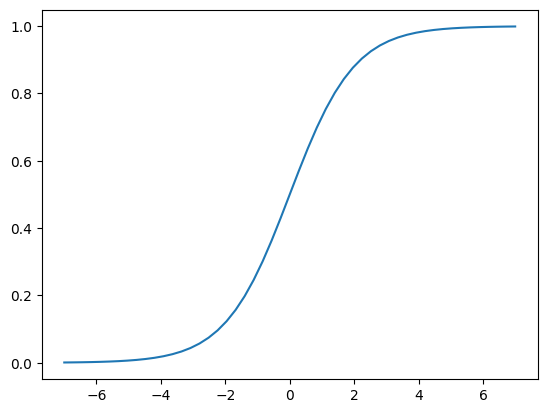

In [90]:
plt.plot(z, sigmoid(z), )

In [91]:
def linear_regression(xi):
    result = w0
    for j in range(len(xi)):
        result += x[j]*w[j]

    return result

In [92]:
def logistic_regression(xi):
    score = w0
    for j in range(len(xi)):
        score += x[j]*w[j]
        
    result = sigmoid(score)
    return result

# 3.10 Training Logistic Regression with Scikit-Learn

In [93]:
# Train a model with Scikit-learn
# Apply it to the validation dataset
# Calculate the accuracy
from sklearn.linear_model import LogisticRegression

In [94]:
model = LogisticRegression()
model.fit(X_train, y_train)

/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [95]:
model.coef_[0].round(3)

array([ 0.564, -0.154, -0.519, -0.013, -0.095,  0.071, -0.098, -0.082,
       -0.033, -0.076, -0.354,  0.343, -0.098,  0.002, -0.251,  0.162,
       -0.02 ,  0.066, -0.098, -0.076,  0.251, -0.098, -0.261, -0.228,
        0.119, -0.121,  0.012, -0.095, -0.03 ,  0.045, -0.028,  0.162,
       -0.271,  0.221, -0.097, -0.098,  0.087, -0.05 , -0.098,  0.039,
        0.194, -0.098, -0.205, -0.072,  0.   ])

In [96]:
# Hard prediction
model.predict(X_train)



array([0, 1, 1, ..., 1, 0, 1], shape=(4225,))

In [99]:
# Soft prediction
y_pred = model.predict_proba(X_val)[:, 1]
y_pred

array([0.00786347, 0.20992803, 0.2237105 , ..., 0.15014869, 0.77668113,
       0.81035774], shape=(1409,))

In [100]:
churn_decision = (y_pred >= 0.5)
churn_decision

array([False, False, False, ..., False,  True,  True], shape=(1409,))

In [101]:
df_val[churn_decision].customerid

3       8433-wxgna
8       3440-jpscl
11      2637-fkfsy
12      7228-omtpn
19      6711-fldfb
           ...    
1397    5976-jcjrh
1398    2034-cgrhz
1399    5276-kqwhg
1407    6521-yytyi
1408    3049-solay
Name: customerid, Length: 322, dtype: str

In [102]:
y_val

array([0, 0, 0, ..., 0, 1, 1], shape=(1409,))

In [103]:
churn_decision.astype(int)

array([0, 0, 0, ..., 0, 1, 1], shape=(1409,))

In [104]:
(y_val == churn_decision).mean()

np.float64(0.801277501774308)

In [105]:
df_pred = pd.DataFrame()
df_pred['probability'] = y_pred
df_pred['prediction'] = churn_decision.astype(int)
df_pred['actual'] = y_val

In [106]:
df_pred

,probability,prediction,actual
0,0.007863,0,0
1,0.209928,0,0
2,0.223710,0,0
3,0.561123,1,1
4,0.219586,0,0
...,...,...,...
1404,0.297790,0,0
1405,0.035463,0,1
1406,0.150149,0,0
1407,0.776681,1,1


In [107]:
df_pred['correct'] = (df_pred['prediction'] == df_pred['actual'])

In [108]:
df_pred

,probability,prediction,actual,correct
0,0.007863,0,0,True
1,0.209928,0,0,True
2,0.223710,0,0,True
3,0.561123,1,1,True
4,0.219586,0,0,True
...,...,...,...,...
1404,0.297790,0,0,True
1405,0.035463,0,1,False
1406,0.150149,0,0,True
1407,0.776681,1,1,True


In [ ]:
df_pred.correct.mean()

np.float64(0.801277501774308)